# Dividend and on-chain activity analysis

This notebook compares declared dividends with values that multiplier updates imply. It also studies mint, burn, and swap activity near critical dates.

All dates and timestamps use UTC. The notebook reads processed CSV files from `output`. It does not change those files.

The analysis uses these critical points:

- The ex-dividend date.
- The payment date.
- The time when the contract emitted the multiplier update.
- The time when the new multiplier became effective.

The analysis shows a timing relationship. It does not prove that a dividend caused an on-chain event.

## Data scope

Mint and burn data covers each dividend scan range. Each range starts seven days before the ex-dividend date. It ends seven days after the payment date.

The NVDA range is partial. Collection stopped at the collection cutoff because the requested end date was still in the future.

Swap data covers only the multiplier-update window. It does not cover every day between the ex-dividend date and the payment date.

Let $d$ be the time from emission to effectiveness. The swap window contains four ranges:

1. $[emit-d, emit)$
2. $[emit, effective)$
3. $[effective, effective+d]$
4. $(effective+d, effective+2d]$

An event at `effective + d` belongs to the third range. This rule prevents a duplicate count.

An empty time outside this window does not mean that no swaps occurred.

In [1]:
from collections import OrderedDict
from datetime import date, datetime, time, timedelta, timezone
from decimal import Decimal, localcontext
import json
import os
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display


UTC = timezone.utc
TICKER_ORDER = ["AAPL", "NVDA", "GOOGL", "MSFT", "META", "MU", "COST"]


def find_repo_root(start=Path.cwd()):
    """Find the repository from the current directory."""
    for candidate in (start, *start.parents):
        if (candidate / "output" / "dividends.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from the repository or from a repository subdirectory."
    )


REPO_ROOT = find_repo_root()
OUTPUT_DIR = Path(os.getenv("STOCK_ACTIVITY_OUTPUT_DIR", REPO_ROOT / "output"))
COLLECTION_PATH = REPO_ROOT / "data" / "raw" / "collection.json"

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
plt.style.use("seaborn-v0_8-whitegrid")

REPO_ROOT

PosixPath('/Users/robert/Work/robinhood-stocks-activity')

In [2]:
def read_csv(name):
    """Read one processed CSV file."""
    return pd.read_csv(OUTPUT_DIR / name)


dividends = read_csv("dividends.csv")
updates = read_csv("multiplier_updates.csv")
pools = read_csv("pools.csv")
mint_burn_events = read_csv("mint_burn_events.csv")
mint_burn_daily = read_csv("mint_burn_daily.csv")
mint_burn_transitions = read_csv("mint_burn_transitions.csv")
swaps = read_csv("swaps.csv")
stored_swap_transitions = read_csv("swap_transitions.csv")
collection = json.loads(COLLECTION_PATH.read_text(encoding="utf-8"))

for column in ["declaration_date", "ex_dividend_date", "record_date", "payment_date"]:
    dividends[column] = pd.to_datetime(dividends[column], utc=True)

for frame, columns in [
    (updates, ["emitted_at", "effective_at"]),
    (mint_burn_events, ["timestamp"]),
    (swaps, ["timestamp"]),
    (stored_swap_transitions, ["timestamp", "window_start", "window_effective", "window_end"]),
]:
    for column in columns:
        if column in frame:
            frame[column] = pd.to_datetime(frame[column], utc=True)

for frame in [mint_burn_daily]:
    frame["date"] = pd.to_datetime(frame["date"], utc=True)

for frame, columns in [
    (mint_burn_daily, ["mint_count", "mint_amount", "burn_count", "burn_amount", "net_issuance"]),
    (swaps, ["stock_bought", "stablecoin_bought"]),
]:
    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")

scan_windows = {
    row["ticker"]: {
        key: pd.Timestamp(row[key])
        for key in ["start", "end", "fetch_end"]
    }
    for row in collection["multiplier_scan_windows"]
}
swap_windows = {
    row["ticker"]: {
        key: pd.Timestamp(row[key])
        for key in ["start", "emission", "effective", "end"]
    }
    for row in collection["swap_windows"]
}

display(Markdown(
    f"Loaded **{len(dividends)}** dividends, **{len(mint_burn_events):,}** mint or burn events, "
    f"and **{len(swaps):,}** swaps."
))

Loaded **7** dividends, **4,775** mint or burn events, and **2,462** swaps.

## Implied dividend method

The method follows the referenced dividend timeline notebook. Yahoo Finance supplies daily unadjusted close prices.

For snapshot supply $S$, old multiplier $M_0$, new multiplier $M_1$, and close price $P$:

1. Calculate underlying shares: $Q=S/M_0$.
2. Calculate the new stock equivalent: $\Delta Q=Q M_1-Q M_0$.
3. Calculate the implied dividend value: $V=\Delta Q\times P$.
4. Calculate the implied value per share equivalent: $D=V/S$.
5. Calculate the difference: $(D-D_{declared})/D_{declared}\times100\%$.

The notebook requests a price window from seven days before through two days after the effective date. It uses the effective-date close when that close exists. Otherwise, it uses the most recent earlier close.

The result is an implied value per stock-token share equivalent. It is not a cash-payment record.

In [3]:
YAHOO_CHART_URL = "https://query1.finance.yahoo.com/v8/finance/chart"
PRICE_LOOKBACK_DAYS = 7
PRICE_LOOKAHEAD_DAYS = 2
YAHOO_HEADERS = {"User-Agent": "Mozilla/5.0"}


def load_price_fixture():
    """Read the optional deterministic price fixture."""
    fixture_path = os.getenv("STOCK_ACTIVITY_YAHOO_FIXTURE")
    if not fixture_path:
        return None
    raw = json.loads(Path(fixture_path).read_text(encoding="utf-8"))
    return {
        symbol: {date.fromisoformat(day): Decimal(str(value)) for day, value in rows.items()}
        for symbol, rows in raw.items()
    }


def yahoo_daily_closes(symbol, start_date, end_date, session):
    """Request unadjusted daily closes from the Yahoo chart endpoint."""
    period1 = int(datetime.combine(start_date, time.min, tzinfo=UTC).timestamp())
    period2 = int(
        datetime.combine(end_date + timedelta(days=1), time.min, tzinfo=UTC).timestamp()
    )
    response = session.get(
        f"{YAHOO_CHART_URL}/{symbol}",
        params={
            "period1": period1,
            "period2": period2,
            "interval": "1d",
            "events": "history",
        },
        headers=YAHOO_HEADERS,
        timeout=30,
    )
    response.raise_for_status()
    chart = response.json()["chart"]
    if chart.get("error"):
        raise RuntimeError(f"Yahoo Finance error for {symbol}: {chart['error']}")
    if not chart.get("result"):
        raise RuntimeError(f"Yahoo Finance returned no chart data for {symbol}.")

    result = chart["result"][0]
    exchange_tz = ZoneInfo(result["meta"].get("exchangeTimezoneName", "UTC"))
    timestamps = result.get("timestamp", [])
    closes = result.get("indicators", {}).get("quote", [{}])[0].get("close", [])
    return {
        datetime.fromtimestamp(timestamp, tz=exchange_tz).date(): Decimal(str(close))
        for timestamp, close in zip(timestamps, closes)
        if close is not None
    }


def close_on_or_before(history, target_date):
    """Select the newest close on or before the target date."""
    available = [session_date for session_date in history if session_date <= target_date]
    if not available:
        raise RuntimeError(f"No Yahoo close exists on or before {target_date}.")
    selected = max(available)
    return selected, history[selected]


price_fixture = load_price_fixture()
price_history_by_symbol = {}
price_errors = {}

required_dates = {}
for ticker in TICKER_ORDER:
    update_dates = updates.loc[updates["ticker"] == ticker, "effective_at"].dt.date.tolist()
    swap_dates = swaps.loc[swaps["ticker"] == ticker, "timestamp"].dt.date.tolist()
    required_dates[ticker] = update_dates + swap_dates

if price_fixture is not None:
    price_history_by_symbol = price_fixture
else:
    with requests.Session() as yahoo_session:
        for ticker, dates in required_dates.items():
            if not dates:
                continue
            try:
                price_history_by_symbol[ticker] = yahoo_daily_closes(
                    ticker,
                    min(dates) - timedelta(days=PRICE_LOOKBACK_DAYS),
                    max(dates) + timedelta(days=PRICE_LOOKAHEAD_DAYS),
                    yahoo_session,
                )
            except Exception as exc:
                price_errors[ticker] = str(exc)

if price_errors:
    display(Markdown(f"Yahoo price errors: `{price_errors}`"))
else:
    display(Markdown("Yahoo close data is available for each stock."))

Yahoo close data is available for each stock.

In [4]:
def calculate_dividend_valuations():
    """Calculate the dividend value that each multiplier update implies."""
    dividend_by_ticker = dividends.set_index("ticker")
    rows = []
    for update in updates.to_dict("records"):
        ticker = update["ticker"]
        reference = dividend_by_ticker.loc[ticker]
        effective_date = update["effective_at"].date()
        history = price_history_by_symbol.get(ticker, {})
        if not history:
            continue
        price_date, close_price = close_on_or_before(history, effective_date)

        snapshot_supply = Decimal(str(update["total_supply_ui"]))
        old_multiplier = Decimal(str(update["old_multiplier"]))
        new_multiplier = Decimal(str(update["new_multiplier"]))
        declared = Decimal(str(reference["amount"]))

        with localcontext() as context:
            context.prec = 50
            underlying_shares = snapshot_supply / old_multiplier
            new_stock_equivalent = underlying_shares * new_multiplier
            old_stock_equivalent = underlying_shares * old_multiplier
            issued_stock_equivalent = new_stock_equivalent - old_stock_equivalent
            implied_total_value = issued_stock_equivalent * close_price
            implied_per_token = implied_total_value / snapshot_supply
            difference = (implied_per_token - declared) / declared * Decimal(100)

        rows.append({
            "ticker": ticker,
            "effective_date": effective_date,
            "yahoo_close_date": price_date,
            "close_usd": float(close_price),
            "snapshot_supply": float(snapshot_supply),
            "old_multiplier": str(old_multiplier),
            "new_multiplier": str(new_multiplier),
            "issued_stock_equivalent": float(issued_stock_equivalent),
            "implied_total_value_usd": float(implied_total_value),
            "implied_dividend_per_share_usd": float(implied_per_token),
            "declared_dividend_per_share_usd": float(declared),
            "difference_percent": float(difference),
        })
    return pd.DataFrame(rows)


valuations = calculate_dividend_valuations()
valuation_columns = [
    "ticker",
    "effective_date",
    "yahoo_close_date",
    "close_usd",
    "implied_dividend_per_share_usd",
    "declared_dividend_per_share_usd",
    "difference_percent",
]
display(valuations[valuation_columns].round(6))

,ticker,effective_date,yahoo_close_date,close_usd,implied_dividend_per_share_usd,declared_dividend_per_share_usd,difference_percent
0,AAPL,2026-08-14,2026-08-14,305.929993,0.173181,0.270,-35.858937
1,NVDA,2026-09-10,2026-09-10,218.360001,0.169264,0.250,-32.294498
2,GOOGL,2026-09-15,2026-09-15,344.980011,0.066900,0.220,-69.590888
3,MSFT,2026-09-11,2026-09-11,495.630005,0.204672,0.910,-77.508606
4,META,2026-09-21,2026-09-21,741.250000,0.401357,0.525,-23.551022
5,MU,2026-07-24,2026-07-24,920.950012,0.068908,0.150,-54.061037
6,COST,2026-08-10,2026-08-10,952.750000,0.583121,1.470,-60.331878


## Multiplier timing groups

Each stock appears in the group for its nearest critical date. A tie goes to the ex-dividend date.

The day differences use calendar dates. A positive value means that effectiveness occurred after the critical date.

In [5]:
timing_rows = []
dividend_by_ticker = dividends.set_index("ticker")

for update in updates.to_dict("records"):
    ticker = update["ticker"]
    reference = dividend_by_ticker.loc[ticker]
    effective_date = update["effective_at"].date()
    ex_date = reference["ex_dividend_date"].date()
    payment_date = reference["payment_date"].date()
    days_from_ex = (effective_date - ex_date).days
    days_from_payment = (effective_date - payment_date).days
    nearest = "ex-date" if abs(days_from_ex) <= abs(days_from_payment) else "payment date"
    timing_rows.append({
        "ticker": ticker,
        "ex_date": ex_date,
        "payment_date": payment_date,
        "effective_date": effective_date,
        "days_from_ex": days_from_ex,
        "days_from_payment": days_from_payment,
        "nearest_critical_date": nearest,
    })

timing = pd.DataFrame(timing_rows)

display(Markdown("### Updates nearest to the ex-dividend date"))
display(timing[timing["nearest_critical_date"] == "ex-date"].reset_index(drop=True))

display(Markdown("### Updates nearest to the payment date"))
display(timing[timing["nearest_critical_date"] == "payment date"].reset_index(drop=True))

### Updates nearest to the ex-dividend date

,ticker,ex_date,payment_date,effective_date,days_from_ex,days_from_payment,nearest_critical_date
0,NVDA,2026-09-10,2026-10-01,2026-09-10,0,-21,ex-date
1,META,2026-09-21,2026-09-28,2026-09-21,0,-7,ex-date


### Updates nearest to the payment date

,ticker,ex_date,payment_date,effective_date,days_from_ex,days_from_payment,nearest_critical_date
0,AAPL,2026-08-10,2026-08-13,2026-08-14,4,1,payment date
1,GOOGL,2026-09-04,2026-09-14,2026-09-15,11,1,payment date
2,MSFT,2026-08-20,2026-09-10,2026-09-11,22,1,payment date
3,MU,2026-07-06,2026-07-21,2026-07-24,18,3,payment date
4,COST,2026-07-24,2026-08-07,2026-08-10,17,3,payment date


## Reusable stock analysis

The function below applies the same checks to each stock. It keeps the source ranges visible so that an empty range has a clear meaning.

In [6]:
SEGMENT_LABELS = OrderedDict([
    ("before_emission", "Before emission"),
    ("emission_to_effective", "Emission to effectiveness"),
    ("effective_to_plus_d", "First interval after effectiveness"),
    ("plus_d_to_plus_2d", "Second interval after effectiveness"),
])

CRITICAL_STYLES = OrderedDict([
    ("Ex-date", {"color": "#9467bd", "linestyle": "--"}),
    ("Payment date", {"color": "#8c564b", "linestyle": "--"}),
    ("Update emitted", {"color": "#ff7f0e", "linestyle": ":"}),
    ("Update effective", {"color": "#d62728", "linestyle": "-"}),
])


def stock_context(ticker):
    """Return the dividend, update, and pool rows for one stock."""
    dividend = dividends.loc[dividends["ticker"] == ticker].iloc[0]
    update = updates.loc[updates["ticker"] == ticker].iloc[0]
    pool = pools.loc[pools["ticker"] == ticker].iloc[0]
    return dividend, update, pool


def dividend_points(dividend):
    """Return the critical dividend dates for mint and burn plots."""
    return OrderedDict([
        ("Ex-date", dividend["ex_dividend_date"]),
        ("Payment date", dividend["payment_date"]),
    ])


def update_points(update):
    """Return the critical update times for swap plots."""
    return OrderedDict([
        ("Update emitted", update["emitted_at"]),
        ("Update effective", update["effective_at"]),
    ])


def points_in_range(points, start, end):
    """Keep critical points that are inside the researched range."""
    return OrderedDict(
        (label, value) for label, value in points.items() if start <= value <= end
    )


def add_critical_lines(axis, points):
    """Add each critical point to one plot."""
    for label, value in points.items():
        axis.axvline(value, linewidth=1.5, label=label, **CRITICAL_STYLES[label])


def round_numeric(frame, places):
    """Round numeric columns and preserve time columns."""
    output = frame.copy()
    numeric_columns = [
        column for column in output.columns
        if pd.api.types.is_numeric_dtype(output[column].dtype)
        and not pd.api.types.is_timedelta64_dtype(output[column].dtype)
    ]
    output[numeric_columns] = output[numeric_columns].round(places)
    return output


def swap_range_axis_labels(summary):
    """Create descriptive labels with actual UTC range times."""
    labels = []
    for row in summary.itertuples():
        start = row.start_utc.strftime("%b %d %H:%M:%S")
        end = row.end_utc.strftime("%b %d %H:%M:%S")
        labels.append(f"{row.range}\n{start} to\n{end} UTC")
    return labels


def add_update_boundary_lines(axis, update):
    """Mark emission and effectiveness between the range bars."""
    emitted = update["emitted_at"].strftime("%b %d %H:%M:%S UTC")
    effective = update["effective_at"].strftime("%b %d %H:%M:%S UTC")
    axis.axvline(
        0.5, linewidth=1.8, label=f"Update emitted: {emitted}",
        **CRITICAL_STYLES["Update emitted"],
    )
    axis.axvline(
        1.5, linewidth=1.8, label=f"Update effective: {effective}",
        **CRITICAL_STYLES["Update effective"],
    )


def show_range_summary(ticker, dividend, update, pool):
    """Show dividend metrics, update metrics, ranges, and pool metadata."""
    scan = scan_windows[ticker]
    window = swap_windows[ticker]
    lag = update["effective_at"] - update["emitted_at"]
    fee_percent = Decimal(str(pool["fee"])) / Decimal(10_000)
    value_row = valuations[valuations["ticker"] == ticker]
    implied_value = np.nan if value_row.empty else value_row.iloc[0]["implied_dividend_per_share_usd"]
    difference_percent = np.nan if value_row.empty else value_row.iloc[0]["difference_percent"]
    nearest_type = {"ex_date": "ex-date", "payment_date": "payment date"}.get(
        update["nearest_dividend_date_type"], update["nearest_dividend_date_type"]
    )
    summary = pd.DataFrame([{
        "ticker": ticker,
        "ex_date": dividend["ex_dividend_date"].date(),
        "payment_date": dividend["payment_date"].date(),
        "update_emitted_utc": update["emitted_at"],
        "update_effective_utc": update["effective_at"],
        "update_delay": lag,
        "mint_burn_start": scan["start"],
        "mint_burn_fetch_end": scan["fetch_end"],
        "swap_start": window["start"],
        "swap_end": window["end"],
        "pool_version": pool["pool_version"],
        "pool_fee_percent": float(fee_percent),
        "declared_dividend_per_share_usd": float(dividend["amount"]),
        "implied_dividend_per_share_usd": implied_value,
        "dividend_difference_percent": difference_percent,
        "multiplier_change_percent": float(update["multiplier_change_pct"]),
        "nearest_dividend_date_type": nearest_type,
        "nearest_dividend_date": update["nearest_dividend_date"],
        "nearest_dividend_days": int(update["nearest_dividend_days"]),
    }])
    display(round_numeric(summary, 6))
    multiplier_change = Decimal(str(update["multiplier_change_pct"]))
    nearest_days = int(update["nearest_dividend_days"])
    day_label = "day" if nearest_days == 1 else "days"
    display(Markdown(
        f"Pool fee: **{fee_percent}%**. "
        f"Multiplier change: **{multiplier_change:.6f}%**. "
        f"Nearest dividend date: **{nearest_type} on {update['nearest_dividend_date']}** "
        f"with a distance of **{nearest_days} calendar {day_label}**."
    ))


def plot_mint_burn_timeline(ticker, points):
    """Plot daily mint and burn counts and daily net issuance."""
    scan = scan_windows[ticker]
    final_day = (scan["fetch_end"] - pd.Timedelta(microseconds=1)).normalize()
    index = pd.date_range(scan["start"].normalize(), final_day, freq="D", tz="UTC")
    daily = mint_burn_daily[mint_burn_daily["ticker"] == ticker].copy()
    value_columns = [
        "mint_count", "mint_amount", "burn_count", "burn_amount", "net_issuance"
    ]
    daily = daily.set_index("date")[value_columns].reindex(index).fillna(0)
    daily[["mint_count", "burn_count"]] = daily[["mint_count", "burn_count"]].astype(int)

    count_figure, count_axis = plt.subplots(figsize=(14, 4))
    count_width = 0.38
    x = mdates.date2num(index.to_pydatetime())

    count_axis.bar(x - count_width / 2, daily["mint_count"], width=count_width, label="Mint count", color="#2ca02c")
    count_axis.bar(x + count_width / 2, daily["burn_count"], width=count_width, label="Burn count", color="#d62728")
    count_axis.set_ylabel("Event count")
    count_axis.set_title(f"{ticker} daily mint and burn counts")
    add_critical_lines(count_axis, points)
    count_axis.legend(loc="best", fontsize=8, ncol=2)
    count_axis.xaxis.set_major_locator(mdates.DayLocator(interval=1, tz=UTC))
    count_axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d", tz=UTC))
    count_figure.autofmt_xdate()
    count_figure.tight_layout()
    plt.show()

    net_figure, net_axis = plt.subplots(figsize=(14, 4))
    net_axis.bar(x, daily["net_issuance"], width=0.7, label="Net issuance", color="#17becf")
    net_axis.axhline(0, color="black", linewidth=0.8)
    net_axis.set_ylabel("Stock-token amount")
    net_axis.set_title(f"{ticker} daily net issuance")
    add_critical_lines(net_axis, points)
    net_axis.legend(loc="best", fontsize=8, ncol=2)
    net_axis.xaxis.set_major_locator(mdates.DayLocator(interval=1, tz=UTC))
    net_axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d", tz=UTC))
    net_figure.autofmt_xdate()
    net_figure.tight_layout()
    plt.show()

    daily_output = daily.reset_index().rename(columns={"index": "date"})
    daily_output["date"] = daily_output["date"].dt.date
    daily_output["total_event_count"] = daily_output["mint_count"] + daily_output["burn_count"]
    display(round_numeric(daily_output[[
        "date", "mint_count", "burn_count", "total_event_count",
        "mint_amount", "burn_amount", "net_issuance",
    ]], 9))


def show_mint_burn_transition(ticker, update):
    """Show mint and burn events from emission until effectiveness."""
    rows = mint_burn_events[
        (mint_burn_events["ticker"] == ticker)
        & (mint_burn_events["timestamp"] >= update["emitted_at"])
        & (mint_burn_events["timestamp"] < update["effective_at"])
    ].copy()
    if rows.empty:
        display(Markdown(
            "**Transition check passed.** No mint or burn event occurred from emission until effectiveness."
        ))
        return
    display(Markdown(
        f"**Transition check needs review.** The range contains **{len(rows)}** mint or burn events."
    ))
    display(rows)


def add_swap_usd_values(events, ticker):
    """Value stock purchases with the Yahoo close for each event date."""
    output = events.copy()
    history = price_history_by_symbol.get(ticker, {})
    values = []
    for row in output.itertuples():
        if not history or not row.stock_bought:
            values.append(0.0 if history else np.nan)
            continue
        _, close = close_on_or_before(history, row.timestamp.date())
        values.append(float(Decimal(str(row.stock_bought)) * close))
    output["stock_bought_usd"] = values
    output["stablecoin_bought_usd_assumed"] = output["stablecoin_bought"]
    return output


def divide_swap_ranges(ticker, update):
    """Assign each collected swap to one of four equal time ranges."""
    emitted = update["emitted_at"]
    effective = update["effective_at"]
    distance = effective - emitted
    boundaries = [
        emitted - distance,
        emitted,
        effective,
        effective + distance,
        effective + 2 * distance,
    ]
    selected = swaps[
        (swaps["ticker"] == ticker)
        & (swaps["timestamp"] >= boundaries[0])
        & (swaps["timestamp"] <= boundaries[4])
    ].copy()
    selected = add_swap_usd_values(selected, ticker)

    conditions = [
        (selected["timestamp"] >= boundaries[0]) & (selected["timestamp"] < boundaries[1]),
        (selected["timestamp"] >= boundaries[1]) & (selected["timestamp"] < boundaries[2]),
        (selected["timestamp"] >= boundaries[2]) & (selected["timestamp"] <= boundaries[3]),
        (selected["timestamp"] > boundaries[3]) & (selected["timestamp"] <= boundaries[4]),
    ]
    selected["range"] = np.select(conditions, list(SEGMENT_LABELS), default="outside")
    selected["range"] = pd.Categorical(
        selected["range"], categories=list(SEGMENT_LABELS), ordered=True
    )

    summary_rows = []
    for key, label in SEGMENT_LABELS.items():
        part = selected[selected["range"] == key]
        summary_rows.append({
            "range": label,
            "start_utc": boundaries[list(SEGMENT_LABELS).index(key)],
            "end_utc": boundaries[list(SEGMENT_LABELS).index(key) + 1],
            "total_swaps": len(part),
            "buy_stock_count": int((part["direction"] == "buy_stock").sum()),
            "buy_stablecoin_count": int((part["direction"] == "buy_stablecoin").sum()),
            "stock_bought": part["stock_bought"].sum(),
            "stablecoin_bought": part["stablecoin_bought"].sum(),
            "stock_bought_usd": part["stock_bought_usd"].sum(),
            "stablecoin_bought_usd_assumed": part["stablecoin_bought_usd_assumed"].sum(),
        })
    return selected, pd.DataFrame(summary_rows)


def show_swap_ranges(ticker, update):
    """Show four-range totals and the two transition ranges."""
    selected, summary = divide_swap_ranges(ticker, update)
    display(Markdown("#### Four-range swap summary"))
    display(round_numeric(summary, 9))

    if selected.empty:
        display(Markdown("No swaps exist in the collected multiplier-update window."))
    else:
        x = np.arange(len(summary))
        axis_labels = swap_range_axis_labels(summary)
        count_width = 0.25
        count_figure, count_axis = plt.subplots(figsize=(14, 4))
        count_axis.bar(x - count_width, summary["total_swaps"], width=count_width, label="Total swaps", color="#7f7f7f")
        count_axis.bar(x, summary["buy_stock_count"], width=count_width, label="Buy stock", color="#1f77b4")
        count_axis.bar(x + count_width, summary["buy_stablecoin_count"], width=count_width, label="Buy stablecoin", color="#ff7f0e")
        count_axis.set_xticks(x, axis_labels)
        count_axis.set_ylabel("Swap count")
        count_axis.set_xlabel("Researched ranges in UTC")
        count_axis.set_title(f"{ticker} swap counts around the multiplier update")
        add_update_boundary_lines(count_axis, update)
        count_axis.legend(loc="best", fontsize=8, ncol=3)
        count_figure.tight_layout()
        plt.show()

        volume_width = 0.34
        volume_figure, volume_axis = plt.subplots(figsize=(14, 4))
        volume_axis.bar(x - volume_width / 2, summary["stock_bought_usd"], width=volume_width, label="Stock bought, USD value", color="#1f77b4")
        volume_axis.bar(x + volume_width / 2, summary["stablecoin_bought_usd_assumed"], width=volume_width, label="Stablecoin bought, USD assumption", color="#ff7f0e")
        volume_axis.set_xticks(x, axis_labels)
        volume_axis.set_ylabel("USD")
        volume_axis.set_xlabel("Researched ranges in UTC")
        volume_axis.set_title(f"{ticker} purchase volume around the multiplier update")
        add_update_boundary_lines(volume_axis, update)
        volume_axis.legend(loc="best", fontsize=8, ncol=2)
        volume_figure.tight_layout()
        plt.show()

    transition = selected[
        selected["range"].isin(["emission_to_effective", "effective_to_plus_d"])
    ].copy()
    stored_count = len(stored_swap_transitions[
        stored_swap_transitions["ticker"] == ticker
    ])
    display(Markdown(
        f"The transition data contains **{len(transition):,}** swaps. "
        f"The stored transition CSV contains **{stored_count:,}** rows for this stock."
    ))
    columns = [
        "range", "timestamp", "direction", "stock_bought", "stock_bought_usd",
        "stablecoin_bought", "stablecoin_bought_usd_assumed",
        "transaction_hash", "log_index",
    ]
    display(transition[columns].reset_index(drop=True))


MU_POOL_FIRST_CODE_BLOCK = 20_656_675
MU_POOL_FIRST_CODE_AT = pd.Timestamp("2026-07-27T10:22:22+00:00")


def show_mu_pool_check(dividend, update, pool):
    """Show the historical bytecode check for the MU pool."""
    if pool["ticker"] != "MU":
        return
    payment_at = dividend["payment_date"]
    existed_on_payment_date = MU_POOL_FIRST_CODE_AT <= payment_at + pd.Timedelta(days=1)
    existed_during_swap_window = MU_POOL_FIRST_CODE_AT <= swap_windows["MU"]["end"]
    result = pd.DataFrame([{
        "pool": pool["pool_address_or_id"],
        "payment_date": payment_at.date(),
        "update_emitted_utc": update["emitted_at"],
        "first_code_block": MU_POOL_FIRST_CODE_BLOCK,
        "first_code_at_utc": MU_POOL_FIRST_CODE_AT,
        "existed_on_payment_date": existed_on_payment_date,
        "existed_during_swap_window": existed_during_swap_window,
    }])
    display(result)
    display(Markdown(
        "The MU pool did not exist on the payment date or during the multiplier-update window. "
        "The swap collector correctly returned zero rows. It cannot analyze MU transition swaps for this event."
    ))


def analyze_stock(ticker):
    """Run the complete activity analysis for one stock."""
    dividend, update, pool = stock_context(ticker)
    scan = scan_windows[ticker]
    mint_burn_points = points_in_range(
        dividend_points(dividend), scan["start"], scan["fetch_end"]
    )
    display(Markdown("### Core metrics and researched ranges"))
    show_range_summary(ticker, dividend, update, pool)

    display(Markdown("### Mint and burn timeline"))
    plot_mint_burn_timeline(ticker, mint_burn_points)
    display(Markdown("### Mint and burn transition check"))
    show_mint_burn_transition(ticker, update)

    display(Markdown("### Swap update ranges"))
    display(Markdown(
        "The charts use the four narrow multiplier-update ranges. "
        "The stock purchase value uses the Yahoo close for each event date. "
        "The stablecoin value assumes that one USDG unit equals one US dollar."
    ))
    show_swap_ranges(ticker, update)
    show_mu_pool_check(dividend, update, pool)

## AAPL

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,AAPL,2026-08-10,2026-08-13,2026-08-14 15:03:06+00:00,2026-08-14 15:12:46+00:00,0 days 00:09:40,2026-08-03 00:00:00+00:00,2026-08-21 00:00:00+00:00,2026-08-14 14:53:26+00:00,2026-08-14 15:32:06+00:00,v4,0.3,0.27,0.173181,-35.858937,0.056608,payment date,2026-08-13,1


Pool fee: **0.3%**. Multiplier change: **0.056608%**. Nearest dividend date: **payment date on 2026-08-13** with a distance of **1 calendar day**.

### Mint and burn timeline

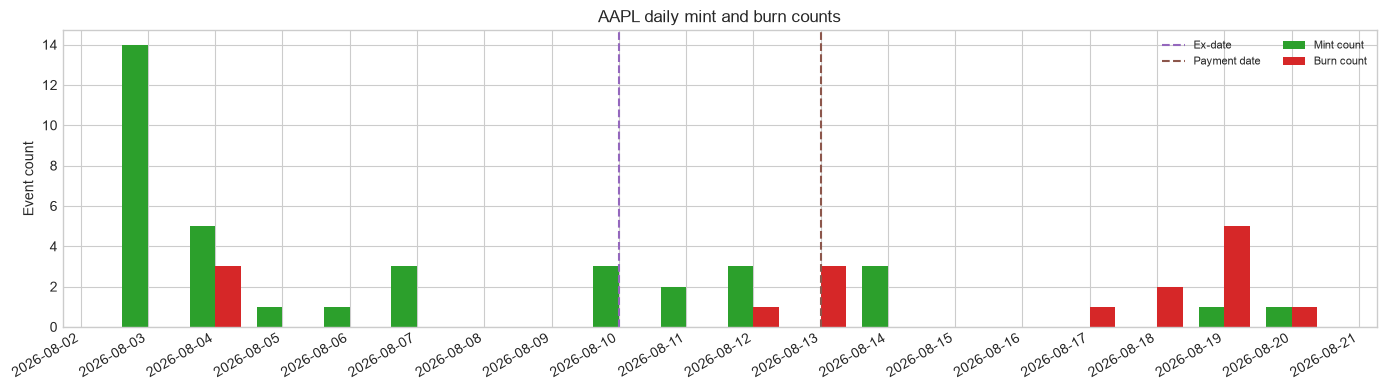

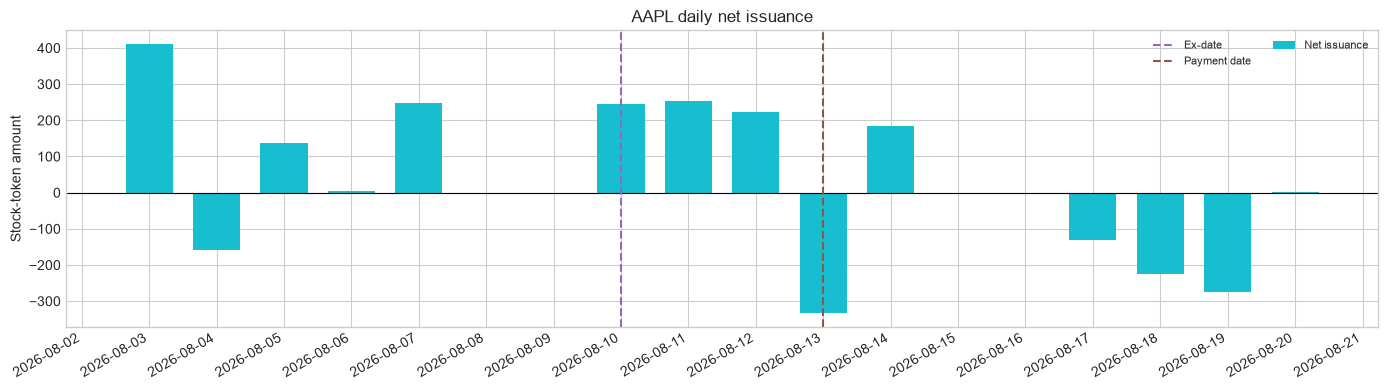

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-08-03,14,0,14,411.164000,0.000000,411.164000
1,2026-08-04,5,3,8,264.140000,422.103000,-157.963000
2,2026-08-05,1,0,1,136.596000,0.000000,136.596000
3,2026-08-06,1,0,1,3.203000,0.000000,3.203000
4,2026-08-07,3,0,3,248.308000,0.000000,248.308000
5,2026-08-08,0,0,0,0.000000,0.000000,0.000000
6,2026-08-09,0,0,0,0.000000,0.000000,0.000000
7,2026-08-10,3,0,3,246.371000,0.000000,246.371000
8,2026-08-11,2,0,2,252.462000,0.000000,252.462000
9,2026-08-12,3,1,4,332.000000,109.915000,222.085000


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

#### Four-range swap summary

,range,start_utc,end_utc,total_swaps,buy_stock_count,buy_stablecoin_count,stock_bought,stablecoin_bought,stock_bought_usd,stablecoin_bought_usd_assumed
0,Before emission,2026-08-14 14:53:26+00:00,2026-08-14 15:03:06+00:00,2,2,0,0.077051,0.000000,23.572142,0.000000
1,Emission to effectiveness,2026-08-14 15:03:06+00:00,2026-08-14 15:12:46+00:00,8,0,8,0.000000,2464.245966,0.000000,2464.245966
2,First interval after effectiveness,2026-08-14 15:12:46+00:00,2026-08-14 15:22:26+00:00,3,1,2,0.016308,143.946383,4.988984,143.946383
3,Second interval after effectiveness,2026-08-14 15:22:26+00:00,2026-08-14 15:32:06+00:00,9,8,1,0.421211,56.381457,128.861146,56.381457


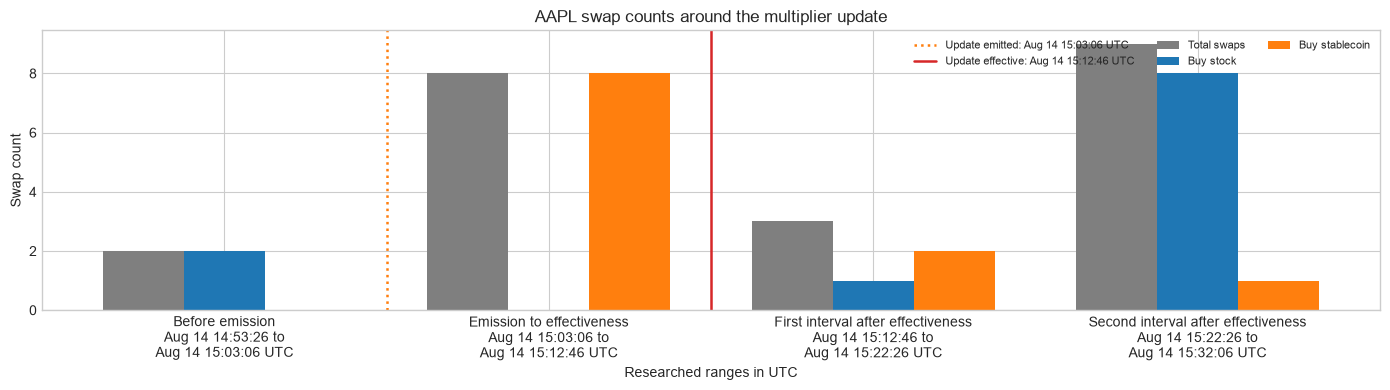

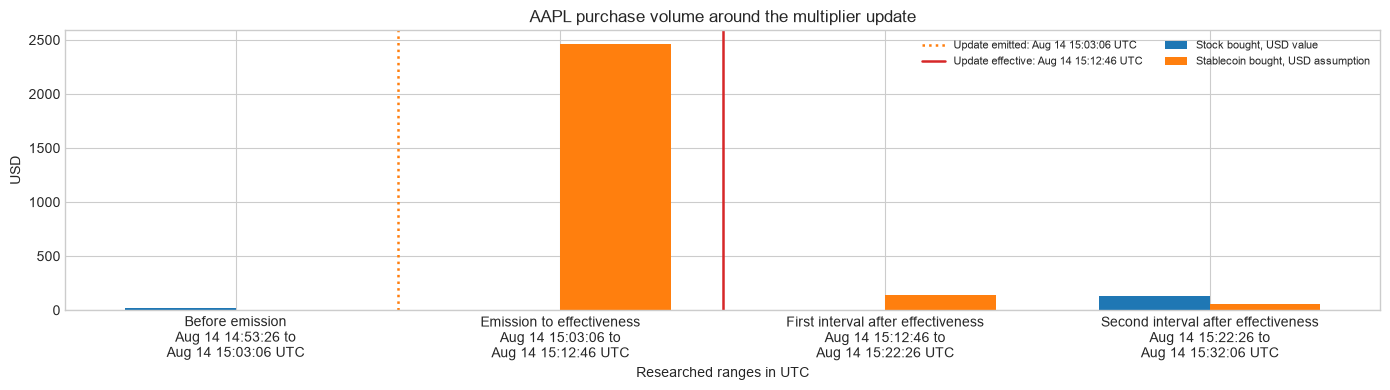

The transition data contains **11** swaps. The stored transition CSV contains **11** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index
0,emission_to_effective,2026-08-14 15:04:11+00:00,buy_stablecoin,0.000000,0.000000,124.589589,124.589589,0x3543e32b945140dec7ac17ae94796b57c144a8681efb83406a2840b7bc891e97,20
1,emission_to_effective,2026-08-14 15:08:20+00:00,buy_stablecoin,0.000000,0.000000,570.846938,570.846938,0xd67e255d5c7d43e44cb0f178297d4061bd51996db55531d194fd3b069c249989,99
2,emission_to_effective,2026-08-14 15:08:27+00:00,buy_stablecoin,0.000000,0.000000,1.089492,1.089492,0x39c7abe712619a9a3d14856d6979242d5de9561c47df10cb8b95d048a568f4cd,49
3,emission_to_effective,2026-08-14 15:08:58+00:00,buy_stablecoin,0.000000,0.000000,416.177693,416.177693,0x41929cf518e75fe8579b1d010bf7a8bc176f76f78cb3fb7475f8ebdbcd2469eb,1
4,emission_to_effective,2026-08-14 15:08:58+00:00,buy_stablecoin,0.000000,0.000000,464.570686,464.570686,0x60bd90969138aff1715f9384717b7472be707c61d9676fe3aac01a4f93bc89d3,12
5,emission_to_effective,2026-08-14 15:09:30+00:00,buy_stablecoin,0.000000,0.000000,382.322985,382.322985,0x1e03f8daa85b2ba23e0673bef27b66accf467a858f6b7cc7817972e0ce18e5e7,4
6,emission_to_effective,2026-08-14 15:10:55+00:00,buy_stablecoin,0.000000,0.000000,352.858784,352.858784,0x52dee93465f1873b7d9259b848a4091413b11a1dbe88f18fd798ff6e66fdaa2c,1
7,emission_to_effective,2026-08-14 15:12:15+00:00,buy_stablecoin,0.000000,0.000000,151.789799,151.789799,0x542d350fdeba1afa01c32551791e267ccff1815b996a88c70a9384744c0da4f1,10
8,effective_to_plus_d,2026-08-14 15:13:09+00:00,buy_stablecoin,0.000000,0.000000,55.793044,55.793044,0x8bb000e9e1ee24a2eac16134935ef16c0dc6d02e128647197b253b6656ad1275,25
9,effective_to_plus_d,2026-08-14 15:13:44+00:00,buy_stock,0.016308,4.988984,0.000000,0.000000,0x2b066b005c564c37beeed1a774bd0f75ceb440a5db05080ef295e5d365b64703,10


In [7]:
analyze_stock("AAPL")

## NVDA

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,NVDA,2026-09-10,2026-10-01,2026-09-09 23:50:42+00:00,2026-09-10 00:00:30+00:00,0 days 00:09:48,2026-09-03 00:00:00+00:00,2026-10-07 11:32:49.595105+00:00,2026-09-09 23:40:54+00:00,2026-09-10 00:20:06+00:00,v3,0.05,0.25,0.169264,-32.294498,0.077516,ex-date,2026-09-10,0


Pool fee: **0.05%**. Multiplier change: **0.077516%**. Nearest dividend date: **ex-date on 2026-09-10** with a distance of **0 calendar days**.

### Mint and burn timeline

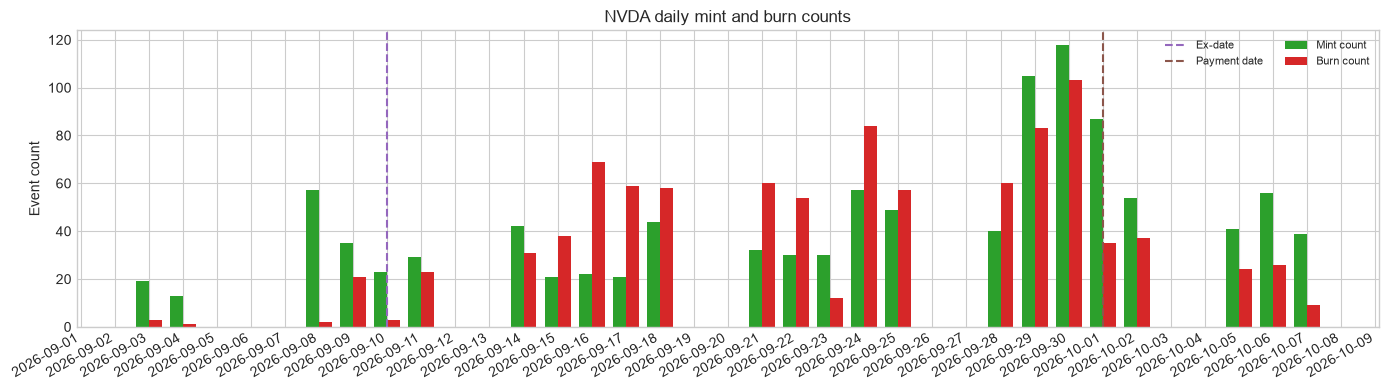

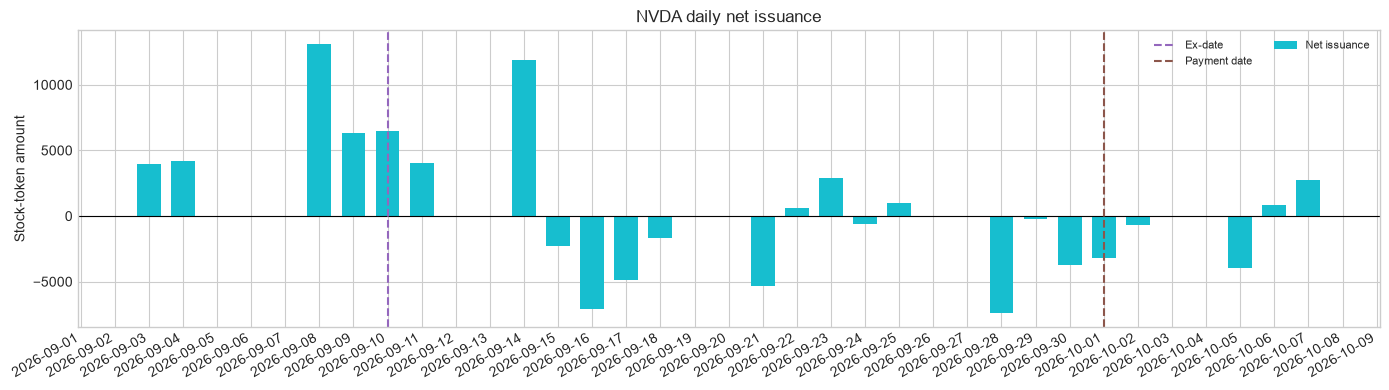

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-09-03,19,3,22,6211.339000,2250.000000,3961.339000
1,2026-09-04,13,1,14,4723.310000,566.000000,4157.310000
2,2026-09-05,0,0,0,0.000000,0.000000,0.000000
3,2026-09-06,0,0,0,0.000000,0.000000,0.000000
4,2026-09-07,0,0,0,0.000000,0.000000,0.000000
5,2026-09-08,57,2,59,13440.740000,330.688000,13110.052000
6,2026-09-09,35,21,56,12856.799000,6530.724000,6326.075000
7,2026-09-10,23,3,26,6881.983368,400.141826,6481.841541
8,2026-09-11,29,23,52,8052.628931,4023.769938,4028.858993
9,2026-09-12,0,0,0,0.000000,0.000000,0.000000


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

#### Four-range swap summary

,range,start_utc,end_utc,total_swaps,buy_stock_count,buy_stablecoin_count,stock_bought,stablecoin_bought,stock_bought_usd,stablecoin_bought_usd_assumed
0,Before emission,2026-09-09 23:40:54+00:00,2026-09-09 23:50:42+00:00,180,71,109,64.331171,41685.987562,14388.952825,41685.987562
1,Emission to effectiveness,2026-09-09 23:50:42+00:00,2026-09-10 00:00:30+00:00,87,37,50,194.457173,7284.945285,42782.955273,7284.945285
2,First interval after effectiveness,2026-09-10 00:00:30+00:00,2026-09-10 00:10:18+00:00,350,183,167,701.455820,95273.717802,153169.893177,95273.717802
3,Second interval after effectiveness,2026-09-10 00:10:18+00:00,2026-09-10 00:20:06+00:00,1076,524,552,296.919727,157148.090666,64835.391803,157148.090666


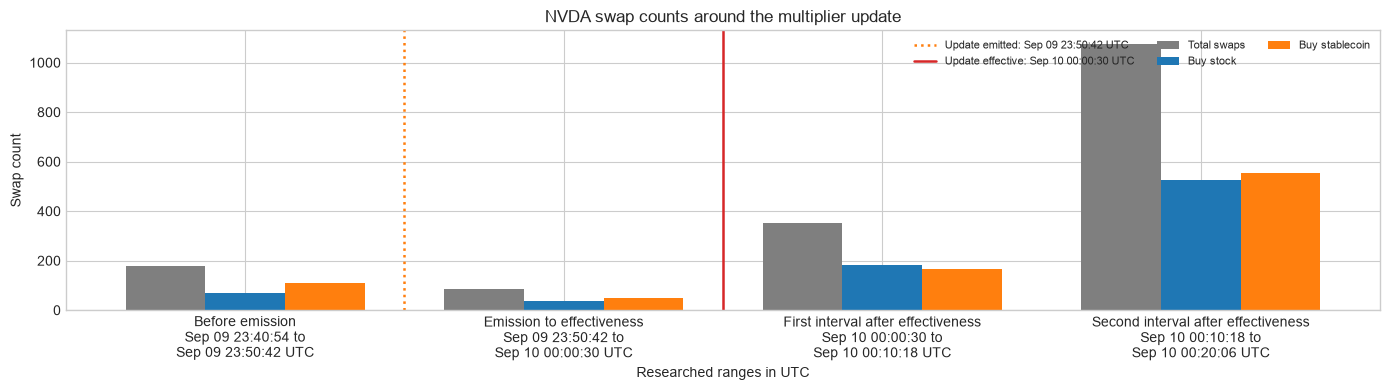

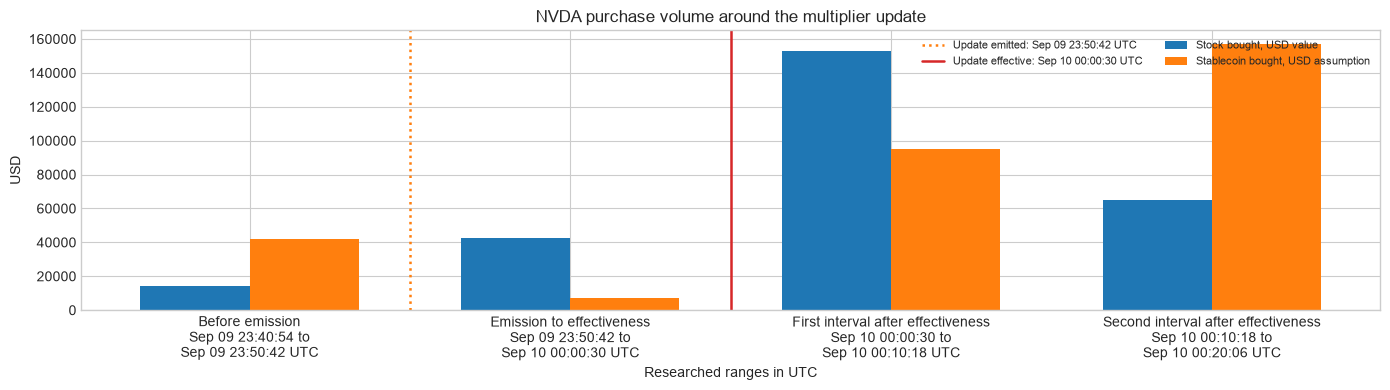

The transition data contains **437** swaps. The stored transition CSV contains **437** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index
0,emission_to_effective,2026-09-09 23:50:49+00:00,buy_stock,0.010914,2.441063,0.000000,0.000000,0x12cfa826654f7036c4fc028227280f39c58724fbb5c5da29f6f15383b9ff436b,8
1,emission_to_effective,2026-09-09 23:50:49+00:00,buy_stablecoin,0.000000,0.000000,1.638141,1.638141,0x2011a026a22913839d87df762ada5d501dcf5e4fd22c8701e510eba131948e4e,63
2,emission_to_effective,2026-09-09 23:50:51+00:00,buy_stablecoin,0.000000,0.000000,78.543067,78.543067,0xd3dd17980b4a03a6f1ce66b3ed61e7a4c18af5f3dd23408d7e38a2123891de9f,94
3,emission_to_effective,2026-09-09 23:50:57+00:00,buy_stock,0.042688,9.547964,0.000000,0.000000,0x0b36853aa345f8d701af7b4a19bca029ee3b7c8a70d4aaaae8aa588511ae051a,7
4,emission_to_effective,2026-09-09 23:50:59+00:00,buy_stablecoin,0.000000,0.000000,2.862208,2.862208,0xfb79f20f2f8b3558a848b33bc6d0c6b98be979df875394bc2ab8836f6a4f3fbf,16
...,...,...,...,...,...,...,...,...,...
432,effective_to_plus_d,2026-09-10 00:10:15+00:00,buy_stock,0.042675,9.318546,0.000000,0.000000,0xe081874bedd018e6a181f1db2f466e04ee5e0652e9850043add5fb58be69894c,24
433,effective_to_plus_d,2026-09-10 00:10:15+00:00,buy_stock,0.109110,23.825190,0.000000,0.000000,0x3b27c298a4db003a5fb51a0707d2267f62d2287f46596bd7492940380361dcaf,14
434,effective_to_plus_d,2026-09-10 00:10:16+00:00,buy_stablecoin,0.000000,0.000000,262.234033,262.234033,0x1a1e631333e28ffae67a9613bf7e2d188ab537a663a348df59f5636354c6ab03,31
435,effective_to_plus_d,2026-09-10 00:10:17+00:00,buy_stock,5.455477,1191.258005,0.000000,0.000000,0x664ce15d3b2b836197cf2b63621c49b60c170a7517142be489844a662ccc61c1,32


In [8]:
analyze_stock("NVDA")

## GOOGL

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,GOOGL,2026-09-04,2026-09-14,2026-09-15 15:00:42+00:00,2026-09-15 15:10:27+00:00,0 days 00:09:45,2026-08-28 00:00:00+00:00,2026-09-22 00:00:00+00:00,2026-09-15 14:50:57+00:00,2026-09-15 15:29:57+00:00,v3,0.05,0.22,0.0669,-69.590888,0.019392,payment date,2026-09-14,1


Pool fee: **0.05%**. Multiplier change: **0.019392%**. Nearest dividend date: **payment date on 2026-09-14** with a distance of **1 calendar day**.

### Mint and burn timeline

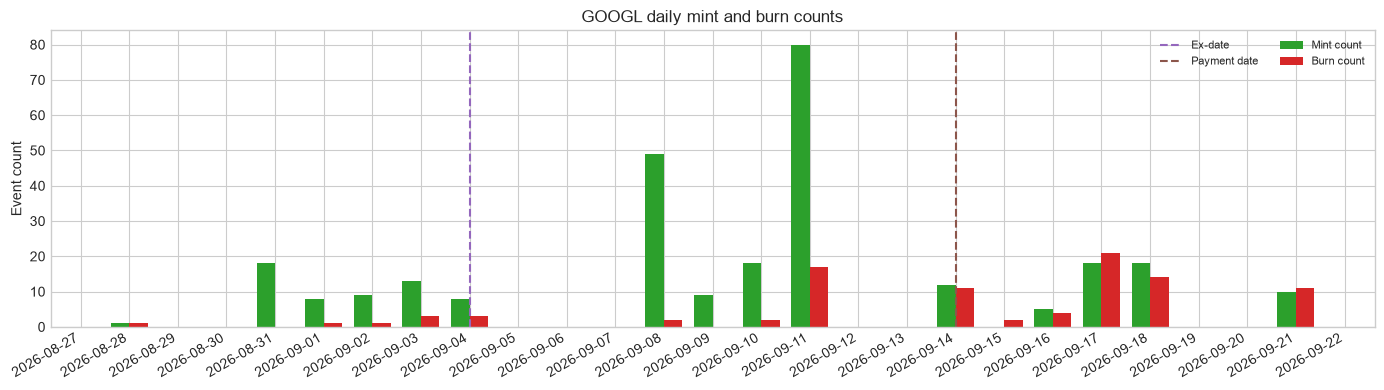

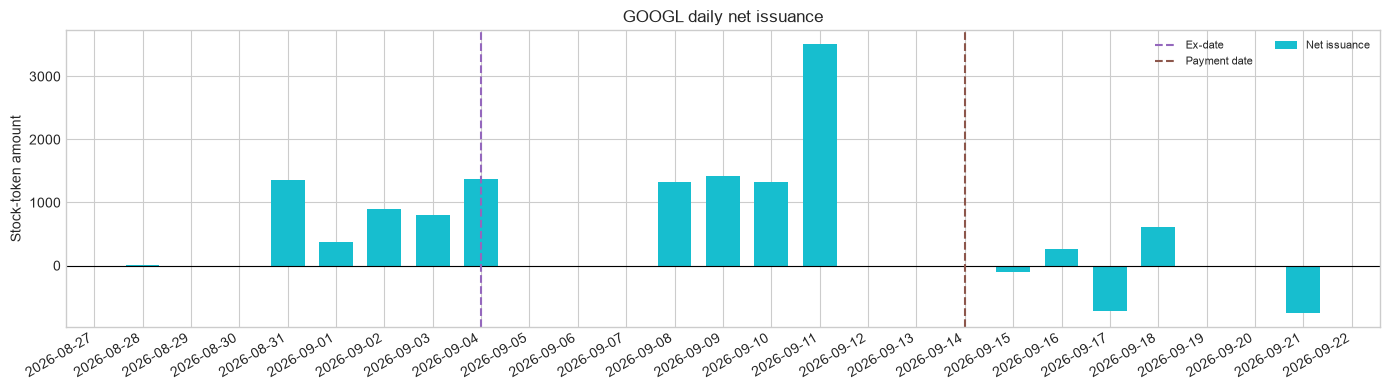

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-08-28,1,1,2,120.000000,115.275000,4.725000
1,2026-08-29,0,0,0,0.000000,0.000000,0.000000
2,2026-08-30,0,0,0,0.000000,0.000000,0.000000
3,2026-08-31,18,0,18,1354.325000,0.000000,1354.325000
4,2026-09-01,8,1,9,473.569000,99.662000,373.907000
5,2026-09-02,9,1,10,1032.031000,135.608000,896.423000
6,2026-09-03,13,3,16,1247.003000,445.977000,801.026000
7,2026-09-04,8,3,11,1661.417000,290.476000,1370.941000
8,2026-09-05,0,0,0,0.000000,0.000000,0.000000
9,2026-09-06,0,0,0,0.000000,0.000000,0.000000


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

#### Four-range swap summary

,range,start_utc,end_utc,total_swaps,buy_stock_count,buy_stablecoin_count,stock_bought,stablecoin_bought,stock_bought_usd,stablecoin_bought_usd_assumed
0,Before emission,2026-09-15 14:50:57+00:00,2026-09-15 15:00:42+00:00,104,43,61,73.843431,31007.379236,25474.507734,31007.379236
1,Emission to effectiveness,2026-09-15 15:00:42+00:00,2026-09-15 15:10:27+00:00,57,38,19,129.132833,14507.175825,44548.246170,14507.175825
2,First interval after effectiveness,2026-09-15 15:10:27+00:00,2026-09-15 15:20:12+00:00,67,25,42,69.162543,39773.124805,23859.694760,39773.124805
3,Second interval after effectiveness,2026-09-15 15:20:12+00:00,2026-09-15 15:29:57+00:00,61,16,45,5.245815,26824.656168,1809.701398,26824.656168


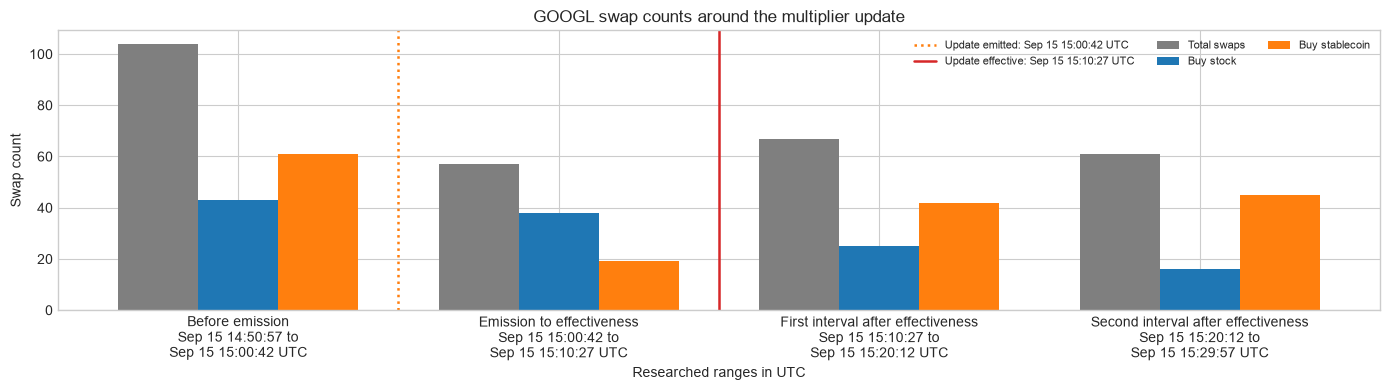

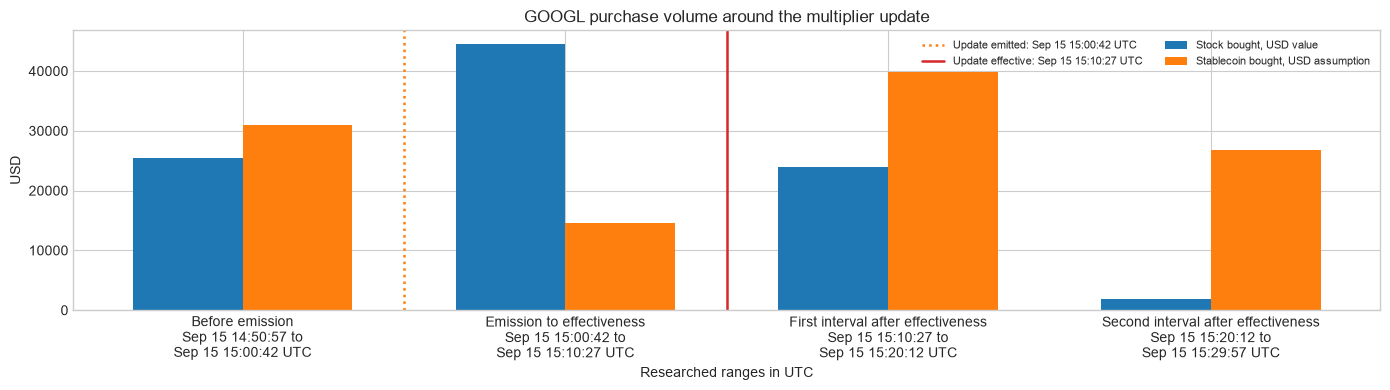

The transition data contains **124** swaps. The stored transition CSV contains **124** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index
0,emission_to_effective,2026-09-15 15:00:55+00:00,buy_stablecoin,0.000000,0.000000,234.703059,234.703059,0xdc66c0b4afe1c3c2be0052e0eda0620cf602b9982167203c26066820ed0a2f9f,85
1,emission_to_effective,2026-09-15 15:01:13+00:00,buy_stablecoin,0.000000,0.000000,212.151106,212.151106,0x9480bfe14b155ae768935f5692f98ccad835c5c29220fae1929d67844daaeacd,112
2,emission_to_effective,2026-09-15 15:01:37+00:00,buy_stock,0.117143,40.411965,0.000000,0.000000,0x1a9b4f8b029a7d3505c000c86477ec3e54cbbdfb4be4c00cf23a8b4aa6a7fe96,8
3,emission_to_effective,2026-09-15 15:01:39+00:00,buy_stablecoin,0.000000,0.000000,1285.290600,1285.290600,0xf7d0c475aa7e2f4fe7ff78c974ace0378f3fab6b6c2a63b22bf576b541d66cce,72
4,emission_to_effective,2026-09-15 15:01:45+00:00,buy_stock,0.344995,119.016403,0.000000,0.000000,0xaa01e47ed024b16a146e53a1e1d4194417ecc333ca692ddde433d3a34ccd0477,41
...,...,...,...,...,...,...,...,...,...
119,effective_to_plus_d,2026-09-15 15:19:45+00:00,buy_stablecoin,0.000000,0.000000,273.716133,273.716133,0xafc62668b904c113fad6539c9680ffab99ec1eb8ceed917c84ff4bffb6fd95aa,33
120,effective_to_plus_d,2026-09-15 15:19:53+00:00,buy_stablecoin,0.000000,0.000000,1881.572353,1881.572353,0x1c859fb8bc2bfedf40d59719fb275cf378a03b267895dfde3d488b94979545bf,3
121,effective_to_plus_d,2026-09-15 15:20:06+00:00,buy_stablecoin,0.000000,0.000000,2020.736109,2020.736109,0x3f5c97cb69ae34c4a6652fbfc4fc329865015b159b18d0e64c671b4b7e160b61,10
122,effective_to_plus_d,2026-09-15 15:20:06+00:00,buy_stablecoin,0.000000,0.000000,3.986741,3.986741,0x17862de859faeea85ad72b1f54fc96e098b68f09af0ae3e62181a1a7f03b6643,97


In [9]:
analyze_stock("GOOGL")

## MSFT

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,MSFT,2026-08-20,2026-09-10,2026-09-11 15:01:46+00:00,2026-09-11 15:10:30+00:00,0 days 00:08:44,2026-08-13 00:00:00+00:00,2026-09-18 00:00:00+00:00,2026-09-11 14:53:02+00:00,2026-09-11 15:27:58+00:00,v3,0.3,0.91,0.204672,-77.508606,0.041295,payment date,2026-09-10,1


Pool fee: **0.3%**. Multiplier change: **0.041295%**. Nearest dividend date: **payment date on 2026-09-10** with a distance of **1 calendar day**.

### Mint and burn timeline

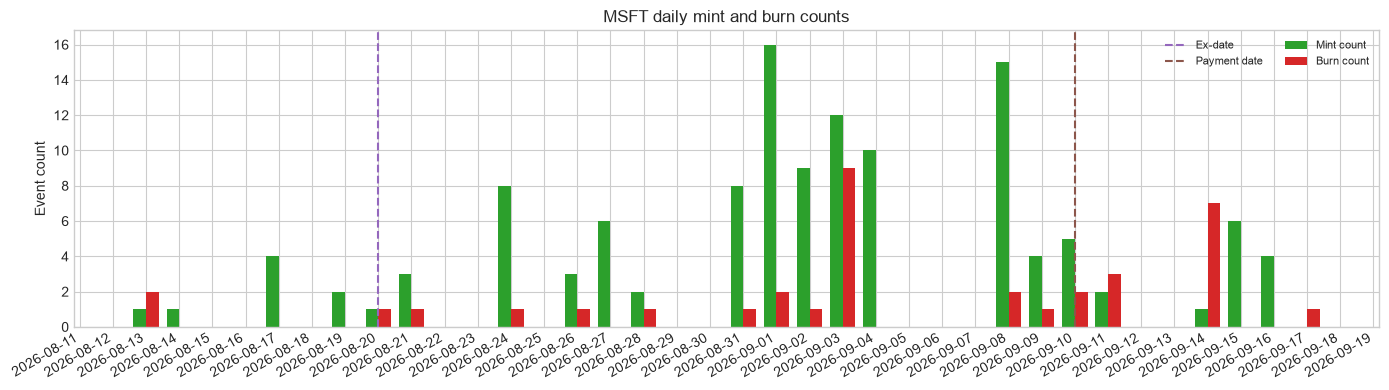

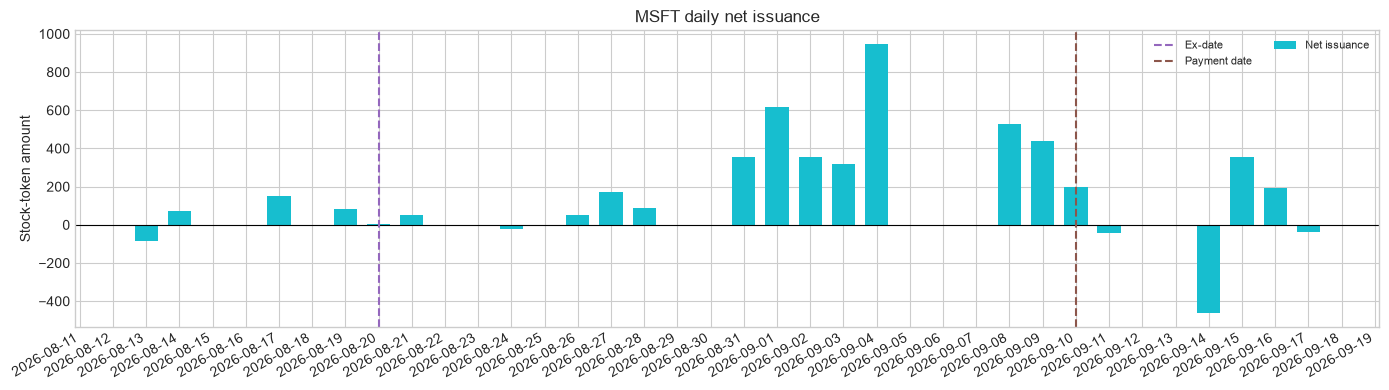

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-08-13,1,2,3,0.045000,83.293000,-83.248000
1,2026-08-14,1,0,1,72.369000,0.000000,72.369000
2,2026-08-15,0,0,0,0.000000,0.000000,0.000000
3,2026-08-16,0,0,0,0.000000,0.000000,0.000000
4,2026-08-17,4,0,4,152.163000,0.000000,152.163000
5,2026-08-18,0,0,0,0.000000,0.000000,0.000000
6,2026-08-19,2,0,2,82.615000,0.000000,82.615000
7,2026-08-20,1,1,2,83.605000,80.000000,3.605000
8,2026-08-21,3,1,4,131.708000,79.503000,52.205000
9,2026-08-22,0,0,0,0.000000,0.000000,0.000000


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

#### Four-range swap summary

,range,start_utc,end_utc,total_swaps,buy_stock_count,buy_stablecoin_count,stock_bought,stablecoin_bought,stock_bought_usd,stablecoin_bought_usd_assumed
0,Before emission,2026-09-11 14:53:02+00:00,2026-09-11 15:01:46+00:00,160,42,118,8.670537,17804.573279,4297.378323,17804.573279
1,Emission to effectiveness,2026-09-11 15:01:46+00:00,2026-09-11 15:10:30+00:00,62,19,43,1.270511,5806.749043,629.703183,5806.749043
2,First interval after effectiveness,2026-09-11 15:10:30+00:00,2026-09-11 15:19:14+00:00,48,24,24,1.951948,2351.336557,967.443763,2351.336557
3,Second interval after effectiveness,2026-09-11 15:19:14+00:00,2026-09-11 15:27:58+00:00,76,65,11,42.990724,2600.844888,21307.492721,2600.844888


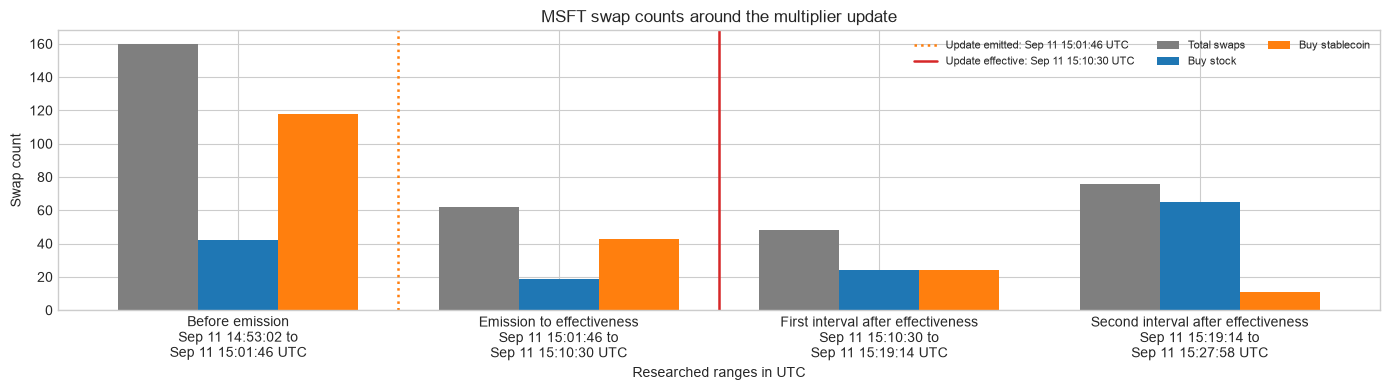

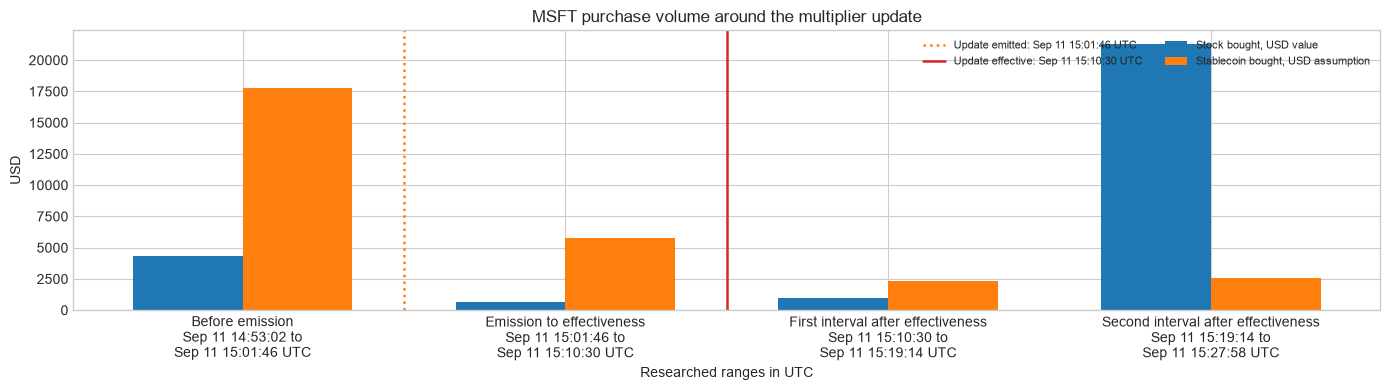

The transition data contains **110** swaps. The stored transition CSV contains **110** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index
0,emission_to_effective,2026-09-11 15:01:52+00:00,buy_stablecoin,0.000000,0.000000,153.689257,153.689257,0xfff4eec620cbfdd459711e991f59116ecd89693ccf37fc45df4ea76d5e4b0cae,101
1,emission_to_effective,2026-09-11 15:01:53+00:00,buy_stablecoin,0.000000,0.000000,3.457757,3.457757,0x0acaedc281e63fb30c504673e82a24bb97336147d2e7204bd865fa94913a880d,108
2,emission_to_effective,2026-09-11 15:02:03+00:00,buy_stablecoin,0.000000,0.000000,204.996890,204.996890,0x696361383269a715e7c4db6b10544ac08104f953f1bc911fc744b9bd869b7ec2,10
3,emission_to_effective,2026-09-11 15:02:05+00:00,buy_stablecoin,0.000000,0.000000,101.376304,101.376304,0xf7171d66cd3e7dca41b66edc47fefe78b722cd17e72fce6ccd9e6adb645d8938,27
4,emission_to_effective,2026-09-11 15:02:05+00:00,buy_stablecoin,0.000000,0.000000,204.740166,204.740166,0xbe63c3c2aabffd1bdad4a9dd879ff85066a2c41b92589a90056e4d77edf5ce80,45
...,...,...,...,...,...,...,...,...,...
105,effective_to_plus_d,2026-09-11 15:16:26+00:00,buy_stablecoin,0.000000,0.000000,0.732776,0.732776,0x81282e09f53af01d4bc36528ed5c78b560a41e3e522169d7d7d620745fa7bac2,16
106,effective_to_plus_d,2026-09-11 15:16:32+00:00,buy_stock,0.104213,51.651166,0.000000,0.000000,0xccaba541297380027626b9935aa58027481ab98020458eb78a4bde507ebb572d,156
107,effective_to_plus_d,2026-09-11 15:17:21+00:00,buy_stock,0.052118,25.831138,0.000000,0.000000,0xccba27df8bb918a024bfcd49597c7ca50fe4e56b21249f5fca5c52e5599c338c,34
108,effective_to_plus_d,2026-09-11 15:18:18+00:00,buy_stock,0.023497,11.645930,0.000000,0.000000,0xddab85f198efe85dd6f9a41abdaea6d073bd66631089b09aab3d5f1a5e6b649a,9


In [10]:
analyze_stock("MSFT")

## META

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,META,2026-09-21,2026-09-28,2026-09-21 00:11:17+00:00,2026-09-21 00:20:36+00:00,0 days 00:09:19,2026-09-14 00:00:00+00:00,2026-10-06 00:00:00+00:00,2026-09-21 00:01:58+00:00,2026-09-21 00:39:14+00:00,v4,0.3,0.525,0.401357,-23.551022,0.054146,ex-date,2026-09-21,0


Pool fee: **0.3%**. Multiplier change: **0.054146%**. Nearest dividend date: **ex-date on 2026-09-21** with a distance of **0 calendar days**.

### Mint and burn timeline

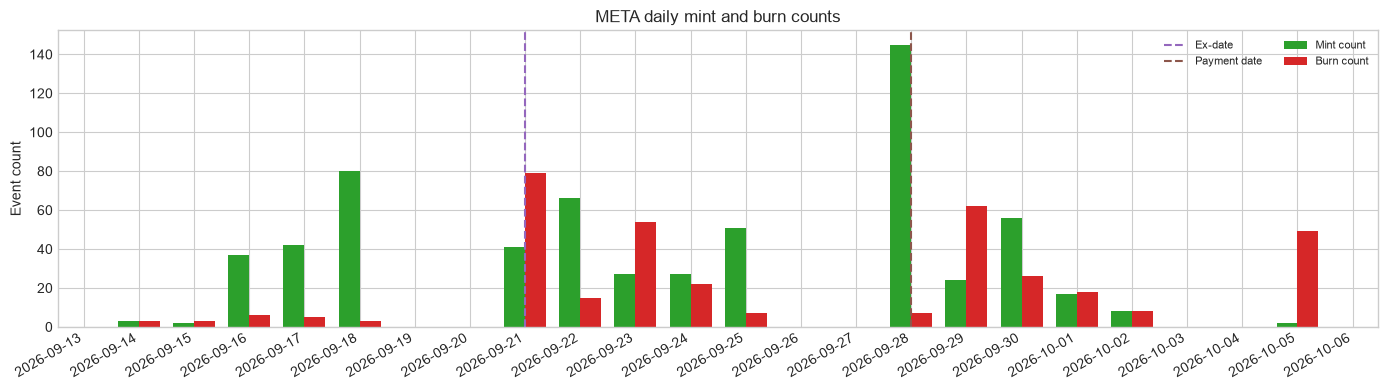

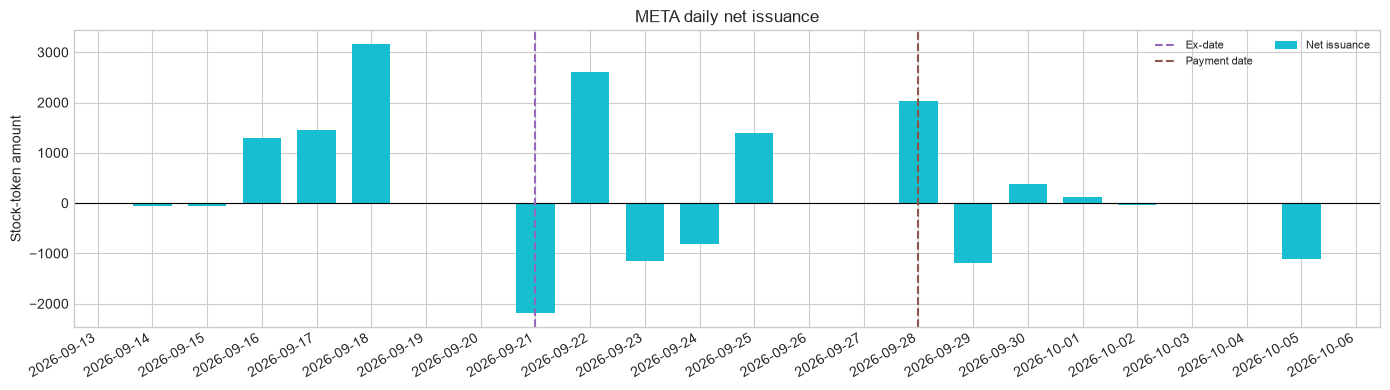

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-09-14,3,3,6,152.693000,211.224000,-58.531000
1,2026-09-15,2,3,5,120.686000,174.892000,-54.206000
2,2026-09-16,37,6,43,1713.639000,410.795000,1302.844000
3,2026-09-17,42,5,47,2021.333000,570.379000,1450.954000
4,2026-09-18,80,3,83,3279.353000,113.973000,3165.380000
5,2026-09-19,0,0,0,0.000000,0.000000,0.000000
6,2026-09-20,0,0,0,0.000000,0.000000,0.000000
7,2026-09-21,41,79,120,1925.526595,4118.721727,-2193.195133
8,2026-09-22,66,15,81,3593.821640,991.484611,2602.337029
9,2026-09-23,27,54,81,977.858809,2131.142732,-1153.283923


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

#### Four-range swap summary

,range,start_utc,end_utc,total_swaps,buy_stock_count,buy_stablecoin_count,stock_bought,stablecoin_bought,stock_bought_usd,stablecoin_bought_usd_assumed
0,Before emission,2026-09-21 00:01:58+00:00,2026-09-21 00:11:17+00:00,90,87,3,219.552649,175.848699,162743.401302,175.848699
1,Emission to effectiveness,2026-09-21 00:11:17+00:00,2026-09-21 00:20:36+00:00,3,2,1,0.204144,1906.282622,151.321535,1906.282622
2,First interval after effectiveness,2026-09-21 00:20:36+00:00,2026-09-21 00:29:55+00:00,0,0,0,0.000000,0.000000,0.000000,0.000000
3,Second interval after effectiveness,2026-09-21 00:29:55+00:00,2026-09-21 00:39:14+00:00,8,2,6,0.102877,1093.012689,76.257864,1093.012689


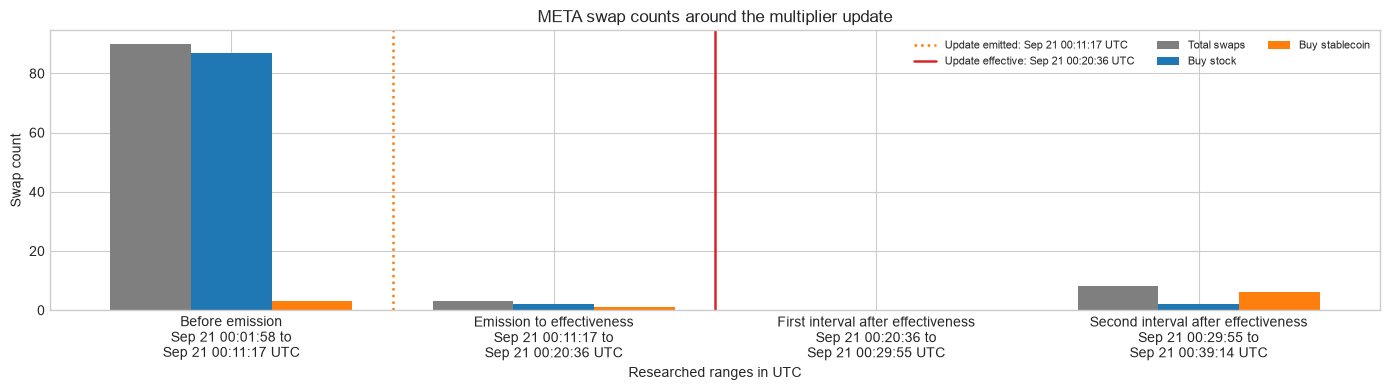

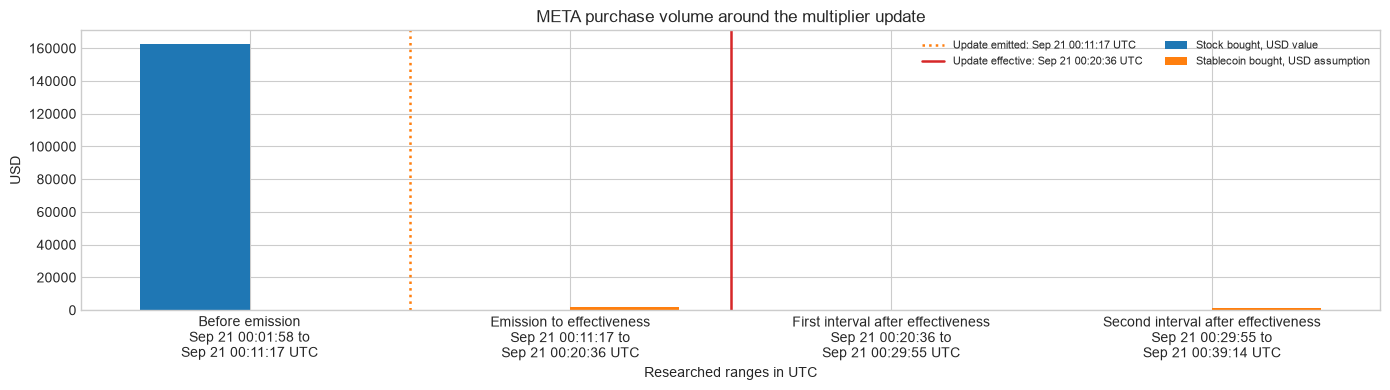

The transition data contains **3** swaps. The stored transition CSV contains **3** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index
0,emission_to_effective,2026-09-21 00:17:19+00:00,buy_stock,0.196256,145.474903,0.000000,0.000000,0x497850586c0a21508a3da568b716490a4e300310bb3e102cd6b5339f17d94bd9,5
1,emission_to_effective,2026-09-21 00:18:24+00:00,buy_stablecoin,0.000000,0.000000,1906.282622,1906.282622,0xfce300f392713928d8629e8f594eb06275c17ab2ad12aebb8e1cab275fb1c98d,47
2,emission_to_effective,2026-09-21 00:19:58+00:00,buy_stock,0.007888,5.846632,0.000000,0.000000,0xcaeb811e4d1b52e203d9d598fc0aa49dcf62ca9b87cacb32a1aa4c091ad33943,10


In [11]:
analyze_stock("META")

## MU

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,MU,2026-07-06,2026-07-21,2026-07-24 15:00:40+00:00,2026-07-24 15:10:24+00:00,0 days 00:09:44,2026-06-29 00:00:00+00:00,2026-07-29 00:00:00+00:00,2026-07-24 14:50:56+00:00,2026-07-24 15:29:52+00:00,v3,0.3,0.15,0.068908,-54.061037,0.007482,payment date,2026-07-21,3


Pool fee: **0.3%**. Multiplier change: **0.007482%**. Nearest dividend date: **payment date on 2026-07-21** with a distance of **3 calendar days**.

### Mint and burn timeline

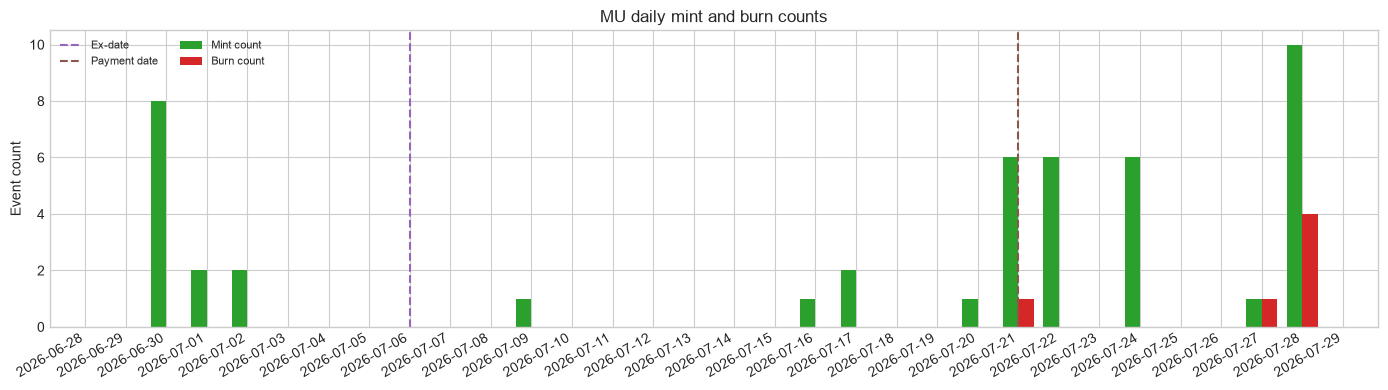

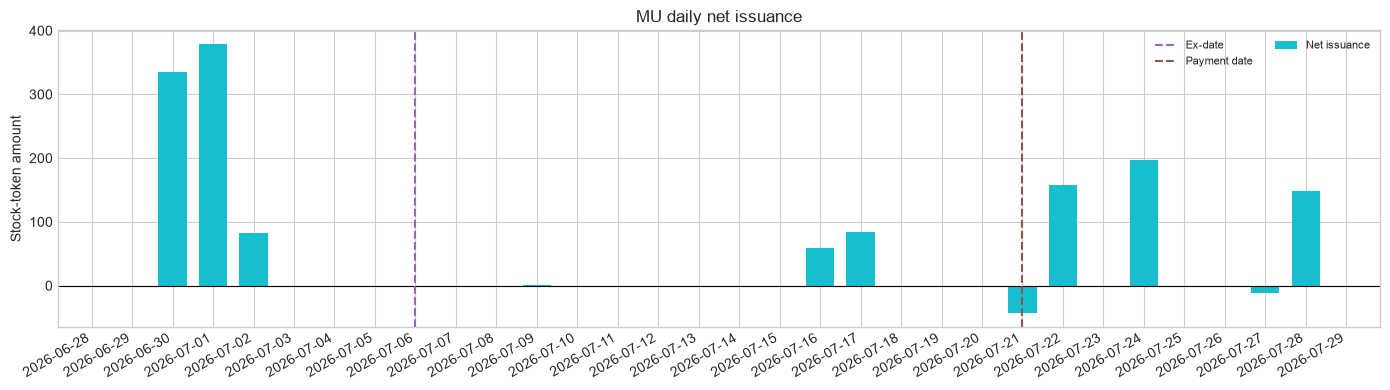

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-06-29,0,0,0,0.000000,0.000000,0.000000
1,2026-06-30,8,0,8,335.309000,0.000000,335.309000
2,2026-07-01,2,0,2,379.055000,0.000000,379.055000
3,2026-07-02,2,0,2,81.794000,0.000000,81.794000
4,2026-07-03,0,0,0,0.000000,0.000000,0.000000
5,2026-07-04,0,0,0,0.000000,0.000000,0.000000
6,2026-07-05,0,0,0,0.000000,0.000000,0.000000
7,2026-07-06,0,0,0,0.000000,0.000000,0.000000
8,2026-07-07,0,0,0,0.000000,0.000000,0.000000
9,2026-07-08,0,0,0,0.000000,0.000000,0.000000


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

...

No swaps exist in the collected multiplier-update window.

The transition data contains **0** swaps. The stored transition CSV contains **0** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index


,pool,payment_date,update_emitted_utc,first_code_block,first_code_at_utc,existed_on_payment_date,existed_during_swap_window
0,0xd057b1bc54917855bbee58ead58647f47cab35e5,2026-07-21,2026-07-24 15:00:40+00:00,20656675,2026-07-27 10:22:22+00:00,False,False


The MU pool did not exist on the payment date or during the multiplier-update window. The swap collector correctly returned zero rows. It cannot analyze MU transition swaps for this event.

In [12]:
analyze_stock("MU")

## COST

### Core metrics and researched ranges

,ticker,ex_date,payment_date,update_emitted_utc,update_effective_utc,update_delay,mint_burn_start,mint_burn_fetch_end,swap_start,swap_end,pool_version,pool_fee_percent,declared_dividend_per_share_usd,implied_dividend_per_share_usd,dividend_difference_percent,multiplier_change_percent,nearest_dividend_date_type,nearest_dividend_date,nearest_dividend_days
0,COST,2026-07-24,2026-08-07,2026-08-10 15:01:06+00:00,2026-08-10 15:10:24+00:00,0 days 00:09:18,2026-07-17 00:00:00+00:00,2026-08-15 00:00:00+00:00,2026-08-10 14:51:48+00:00,2026-08-10 15:29:00+00:00,v3,0.3,1.47,0.583121,-60.331878,0.061204,payment date,2026-08-07,3


Pool fee: **0.3%**. Multiplier change: **0.061204%**. Nearest dividend date: **payment date on 2026-08-07** with a distance of **3 calendar days**.

### Mint and burn timeline

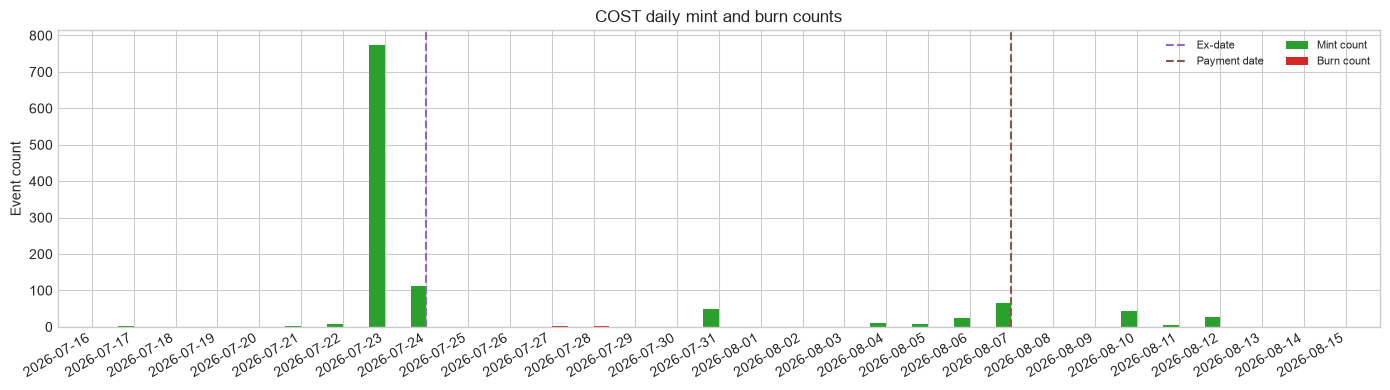

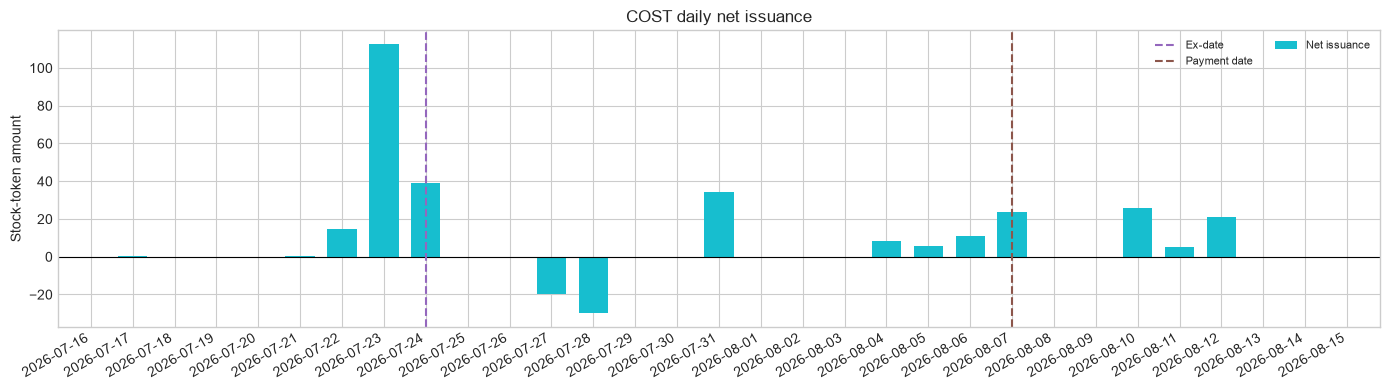

,date,mint_count,burn_count,total_event_count,mint_amount,burn_amount,net_issuance
0,2026-07-17,1,0,1,0.568000,0.0,0.568000
1,2026-07-18,0,0,0,0.000000,0.0,0.000000
2,2026-07-19,0,0,0,0.000000,0.0,0.000000
3,2026-07-20,0,0,0,0.000000,0.0,0.000000
4,2026-07-21,1,0,1,0.214000,0.0,0.214000
5,2026-07-22,7,0,7,14.707000,0.0,14.707000
6,2026-07-23,775,0,775,112.711000,0.0,112.711000
7,2026-07-24,112,0,112,38.856000,0.0,38.856000
8,2026-07-25,0,0,0,0.000000,0.0,0.000000
9,2026-07-26,0,0,0,0.000000,0.0,0.000000


### Mint and burn transition check

**Transition check passed.** No mint or burn event occurred from emission until effectiveness.

### Swap update ranges

The charts use the four narrow multiplier-update ranges. The stock purchase value uses the Yahoo close for each event date. The stablecoin value assumes that one USDG unit equals one US dollar.

#### Four-range swap summary

,range,start_utc,end_utc,total_swaps,buy_stock_count,buy_stablecoin_count,stock_bought,stablecoin_bought,stock_bought_usd,stablecoin_bought_usd_assumed
0,Before emission,2026-08-10 14:51:48+00:00,2026-08-10 15:01:06+00:00,3,3,0,1.119814,0.000000,1066.902765,0.000000
1,Emission to effectiveness,2026-08-10 15:01:06+00:00,2026-08-10 15:10:24+00:00,2,0,2,0.000000,299.461037,0.000000,299.461037
2,First interval after effectiveness,2026-08-10 15:10:24+00:00,2026-08-10 15:19:42+00:00,4,0,4,0.000000,1052.834531,0.000000,1052.834531
3,Second interval after effectiveness,2026-08-10 15:19:42+00:00,2026-08-10 15:29:00+00:00,2,0,2,0.000000,966.165883,0.000000,966.165883


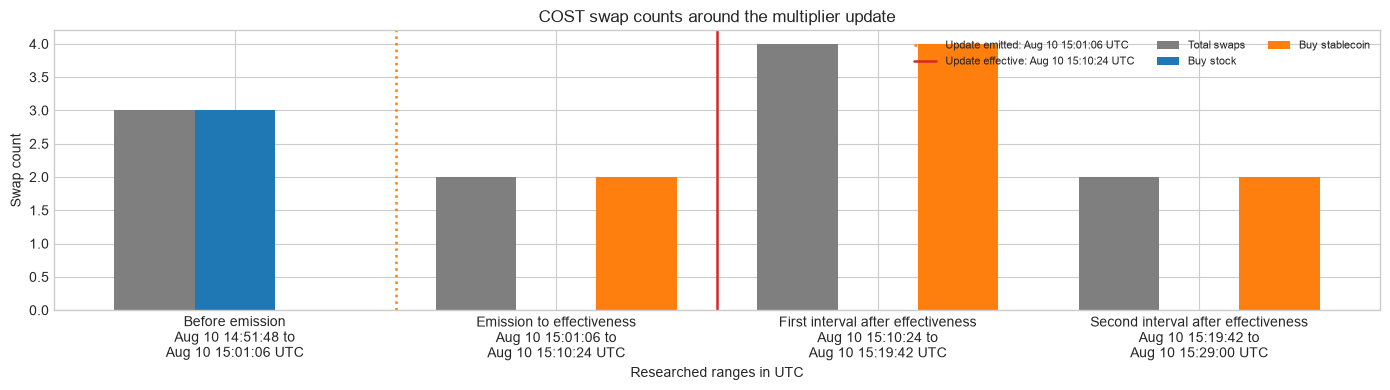

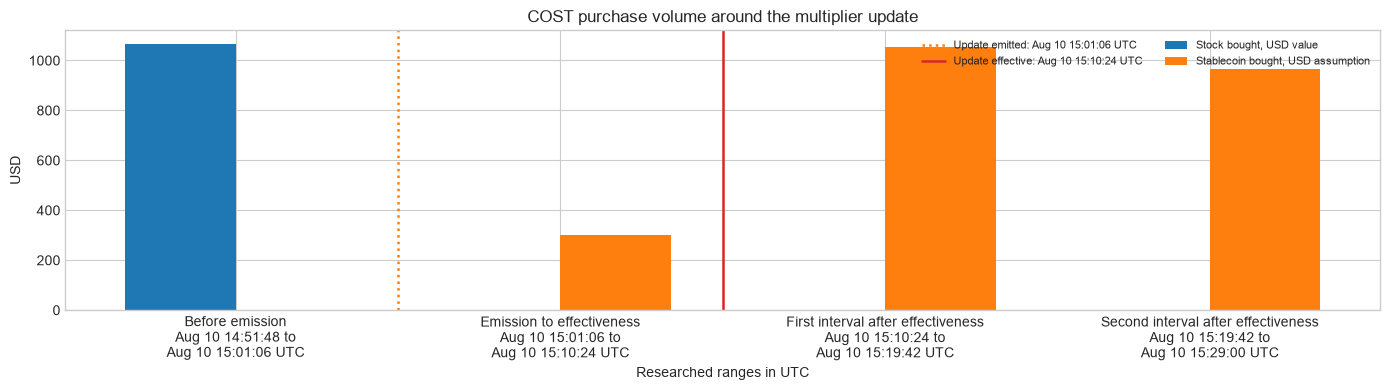

The transition data contains **6** swaps. The stored transition CSV contains **6** rows for this stock.

,range,timestamp,direction,stock_bought,stock_bought_usd,stablecoin_bought,stablecoin_bought_usd_assumed,transaction_hash,log_index
0,emission_to_effective,2026-08-10 15:06:09+00:00,buy_stablecoin,0.0,0.0,247.534398,247.534398,0x725e9d55d0fb470c84327608ff8034306fcee8a8f1cea3232bb50eacdade1304,62
1,emission_to_effective,2026-08-10 15:09:43+00:00,buy_stablecoin,0.0,0.0,51.926639,51.926639,0x4800f34b7648ed4502bc0242464c146e8dd66a156cc98c08138fda59e74a4547,16
2,effective_to_plus_d,2026-08-10 15:10:39+00:00,buy_stablecoin,0.0,0.0,5.423682,5.423682,0xe7dd08a287478f44907536a671a09f9a67a19b4e41b20255549ecd7a43bd1f0e,64
3,effective_to_plus_d,2026-08-10 15:13:28+00:00,buy_stablecoin,0.0,0.0,43.420067,43.420067,0x546e2e1f23715b8a8c561d3adfd70c794fb6e94cf4743c565bc132c1ef4d4cbb,150
4,effective_to_plus_d,2026-08-10 15:15:40+00:00,buy_stablecoin,0.0,0.0,3.359246,3.359246,0xc5893ba76d26bd5a0de6e0c009628cf26fb3f1f384193ca4290089755b7e318b,73
5,effective_to_plus_d,2026-08-10 15:17:37+00:00,buy_stablecoin,0.0,0.0,1000.631536,1000.631536,0x814a7dde9cd012b8b774bc676bc793d42378455a09587e2d6f3617513ec0032f,16


In [13]:
analyze_stock("COST")

## Interpretation limits

- Yahoo closes value stock-token purchases. They do not measure the executed pool price.
- The stablecoin calculation assumes a value of one US dollar per USDG unit.
- Swap totals use only the four collected multiplier-update ranges.
- Mint and burn totals include only the dividend scan range.
- Timing alignment does not prove causation.
- The MU deployment time comes from a historical `eth_getCode` binary search. The first bytecode block was 20,656,675.